# Feature selection

XXXXXXXXXXXXX

In [15]:
import pandas as pd
import numpy as np
from scipy.stats import zscore, linregress
import matplotlib.pyplot as plt
import sys
import geopandas as gpd
import statsmodels.formula.api as smf
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_score, KFold, cross_val_predict, cross_validate
from sklearn.linear_model import LinearRegression
import shap
import seaborn as sns

def grouped_permutation_importance(model, X, y, groups, n_repeats=10, random_state=42):
    """
    groups: dict mapping group_name -> list of column names to permute together
    """
    rng = np.random.RandomState(random_state)
    baseline_score = model.score(X, y)
    results = {}
    
    for group_name, cols in groups.items():
        drop_scores = []
        for _ in range(n_repeats):
            X_permuted = X.copy()
            # Shuffle all columns in the group using the SAME row order,
            # so their joint relationship is scrambled together
            shuffled_idx = rng.permutation(len(X_permuted))
            X_permuted[cols] = X_permuted[cols].values[shuffled_idx]
            score = model.score(X_permuted, y)
            drop_scores.append(baseline_score - score)
        results[group_name] = {
            'importance_mean': np.mean(drop_scores),
            'importance_std': np.std(drop_scores)
        }
    return pd.DataFrame(results).T.sort_values('importance_mean', ascending=False)

def loco_test(X_full, y, drop_var, cv):
    X_reduced = X_full.drop(columns=[drop_var])
    rf_test = RandomForestRegressor(n_estimators=100, random_state=42)
    r2 = cross_val_score(rf_test, X_reduced, y, cv=cv, scoring='r2').mean()
    return r2

def loco_test_vars(X_full, y, drop_vars, cv):
    X_reduced = X_full.drop(columns=drop_vars)
    rf_test = RandomForestRegressor(n_estimators=100, random_state=42)
    r2 = cross_val_score(rf_test, X_reduced, y, cv=cv, scoring='r2').mean()
    return r2

def find_linear_relationship (df, variable1):
    x = df[variable1]
    y = df["10cm_area"]

    # Simple regression: flood area ~ rainfall intensity
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    r2_simple = r_value**2
    if p_value <0.005:
        p_value = '<0.05'
    else:
        p_value = round(p_value, 2)
    # print(" Simple:", f"{r2_simple:.2f}", p_value)  
    return [r2_simple, p_value]

sys.path.insert(1, '../../ProcessEvents')
from config import CATCHMENT_LOOKUP_DICT, ENSEMBLE_MEMBERS, CATCHMENTS

### Get event data

In [16]:
fp = f"/scratch/hydro4/users/kv25483/FutureFlood/Data/EventDetails_v4/all_catchments.pkl"
rainfall_events_all_df = pd.read_pickle(fp)
rainfall_events_all_df = rainfall_events_all_df[rainfall_events_all_df['max_precip']<130].copy()
rainfall_events_all_df["length"] = (rainfall_events_all_df["stop_idx"] - rainfall_events_all_df["start_idx"]).astype("float32")
rainfall_events_all_df['random_variable'] = np.random.normal(size=len(rainfall_events_all_df))
rainfall_events_all_df = rainfall_events_all_df[rainfall_events_all_df['10cm_area']<4].copy()

### Get rid of events with no flooding (idea of zero-inflation in flooded area messing with model performance)

In [17]:
rainfall_events_all_df=rainfall_events_all_df[rainfall_events_all_df['10cm_area']>0.1]

### Set NAN values to 0 (as they should represent the same thing)

In [18]:
rainfall_events_all_df[['peak_cell_outflow_N', 
                        'peak_cell_outflow_S', 'peak_cell_outflow_E','peak_cell_outflow_W']]=rainfall_events_all_df[[
    'peak_cell_outflow_N', 'peak_cell_outflow_S', 'peak_cell_outflow_E','peak_cell_outflow_W']].fillna(value=0)

In [19]:
for level in ['t50', 't60', 't80']:
    rainfall_events_all_df[f'cluster_mean_intensity_{level}'] = (
        rainfall_events_all_df[f'cluster_rain_total_{level}'] / rainfall_events_all_df[f'cluster_n_cells_{level}'].replace(0, np.nan))

### Get smaller subset for fitting the model quicker (for testing)

In [20]:
subset = rainfall_events_all_df# [rainfall_events_all_df["catchment_num"].isin(['33_b', '23', '105', '40', '106', '25'])].copy()
subset = subset.sample(n=5000, random_state=12)  # adjust size to something that runs in seconds
subset.reset_index(inplace=True, drop=True)

### Feature selection

Remove variables which carry no meaning

In [21]:
variables = list(subset.columns)
to_be_removed = {'x_coord', 'y_coord',
                'x_idx', 'y_idx', 'x_idx_global', "y_idx_global", 't_global','t_local', "day_360", "month",
                 "max_precip_from_csv", "event_num", "time_mismatch", "ens",  'start_idx', 'stop_idx',
                 "t_local_rebased", "times", "values", "mismatch", 'n_valid', 'pct_over1', 'pct_under0',
                # "10cm_volume", "30cm_area", "30cm_volume", "10cm_area", 
                'mean_sm_3_before_event', 'mean_sm_4_before_event', 'mean_sm_5_before_event', 'neighbourhood_flood_10_area',
                 'neighbourhood_flood_10_vol', 'neighbourhood_flood_30_area', 'neighbourhood_flood_30_vol',
                'threshold_flood_10_area_t50', 'cluster_flood_10_area_t50',  'threshold_flood_10_vol_t50',
                 'cluster_flood_10_vol_t50', 'threshold_flood_30_area_t50', 'cluster_flood_30_area_t50',
                 'threshold_flood_30_vol_t50','cluster_flood_30_vol_t50','threshold_flood_10_area_t60',
                 'cluster_flood_10_area_t60','threshold_flood_10_vol_t60','cluster_flood_10_vol_t60',
                 'threshold_flood_30_area_t60','cluster_flood_30_area_t60','threshold_flood_30_vol_t60',
                 'cluster_flood_30_vol_t60','threshold_flood_10_area_t80', 'cluster_flood_10_area_t80',
                 'threshold_flood_10_vol_t80', 'cluster_flood_10_vol_t80', 'threshold_flood_30_area_t80',
                 'cluster_flood_30_area_t80', 'threshold_flood_30_vol_t80','cluster_flood_30_vol_t80', 
                 'event_num.1', 'date','Unnamed: 0', 'peak_cell_id',"rainfall_peak_day", "catchment_num",
                 'peak_cell_edge_truncated_N', 'peak_cell_edge_truncated_S', 'peak_cell_edge_truncated_E',
                 'peak_cell_edge_truncated_W',"peak_cell_near_catchment_boundary",
                 #'se_min', 'se_max'
                }

subset = subset.drop(columns=to_be_removed, errors='ignore').copy()
# subset = subset.dropna().copy()

Remove variables which describe rainfall inputs at different spatial scales

- Threshold: any cell anywhere in the domain with rainfall over a certain threshold
- Cluster: cells with rainfall over a certain threshold, which are contiguous with the peak rainfall cell
- Neighbourhood: cells within a fixed spatial window around the peak cell. All rainfall in any of those cells is counted

Cluster seems to be the most physically meaningful option.

In [22]:
# topo_vars = [#'x_coord' , 'y_coord', 
#             'peak_cell_slope_avg', 'peak_cell_slope_max', 'peak_cell_elev_avg', 'peak_cell_elev_max', 'peak_cell_elev_min', 
#              'catchment_slope_avg', 'catchment_slope_max', 'catchment_elev_avg', 'catchment_elev_max', 'catchment_elev_min',
#              'peak_cell_sink_frac', 'peak_cell_outflow_N', 'peak_cell_outflow_S', 'peak_cell_outflow_E', 'peak_cell_outflow_W',
#              'peak_cell_water_prop', 'peak_cell_urban_prop', 'peak_cell_inside_prop','peak_cell_net_flux_score']

# corr = subset[topo_vars].corr(method='spearman')

# plt.figure(figsize=(10, 10))
# sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1)
# plt.tight_layout()
# plt.show()

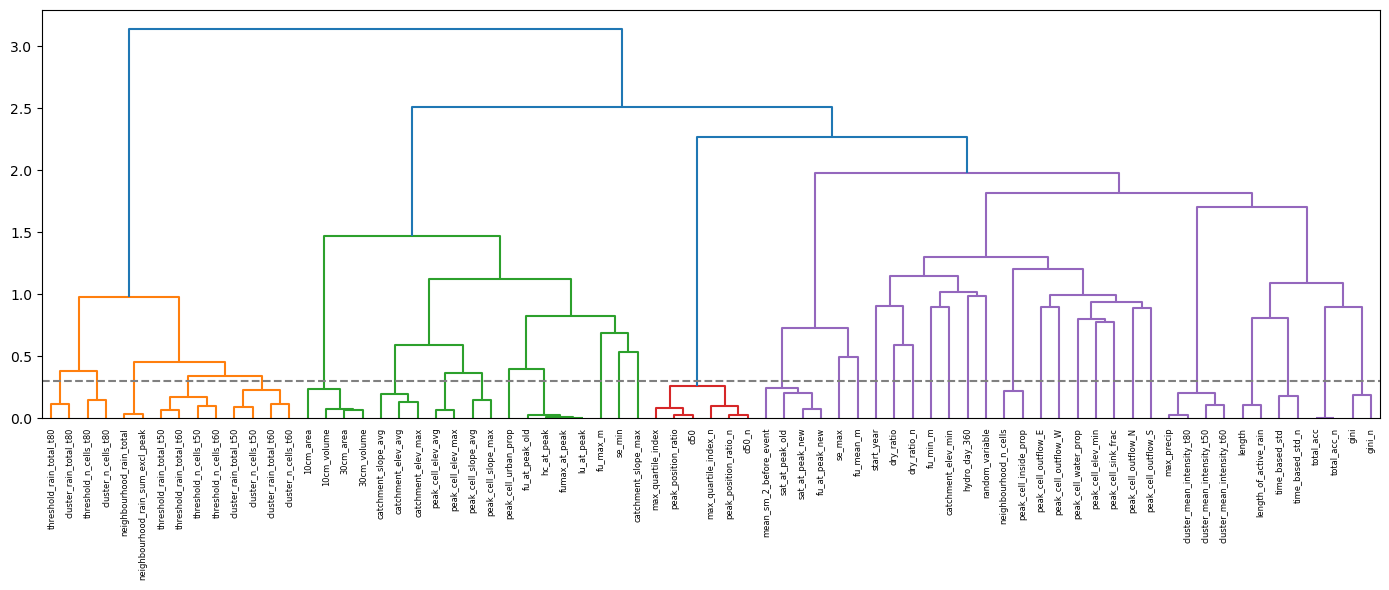

Group 1: ['threshold_rain_total_t80', 'threshold_n_cells_t80', 'cluster_rain_total_t80', 'cluster_n_cells_t80']
Group 2: ['neighbourhood_rain_total', 'neighbourhood_rain_sum_excl_peak', 'threshold_rain_total_t50', 'threshold_n_cells_t50', 'cluster_rain_total_t50', 'cluster_n_cells_t50', 'threshold_rain_total_t60', 'threshold_n_cells_t60', 'cluster_rain_total_t60', 'cluster_n_cells_t60']
Group 3: ['10cm_area', '10cm_volume', '30cm_area', '30cm_volume']
Group 4: ['catchment_slope_avg', 'catchment_elev_avg', 'catchment_elev_max']
Group 5: ['peak_cell_slope_avg', 'peak_cell_slope_max', 'peak_cell_elev_avg', 'peak_cell_elev_max']
Group 6: ['hc_at_peak', 'fu_at_peak_old', 'fumax_at_peak', 'lu_at_peak', 'peak_cell_urban_prop']
Group 10: ['peak_position_ratio', 'd50', 'max_quartile_index', 'peak_position_ratio_n', 'd50_n', 'max_quartile_index_n']
Group 11: ['mean_sm_2_before_event', 'sat_at_peak_new', 'sat_at_peak_old', 'fu_at_peak_new']
Group 12: ['se_max', 'fu_mean_m']
Group 20: ['neighbourh

In [23]:
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

corr = subset.corr(method='spearman').abs()
dist = 1 - corr
condensed = squareform(dist, checks=False)
linkage = hierarchy.ward(condensed)

plt.figure(figsize=(14, 6))
hierarchy.dendrogram(linkage, labels=subset.columns, leaf_rotation=90)
plt.axhline(0.3, color='grey', linestyle='--')
plt.tight_layout()
plt.show()

from scipy.cluster.hierarchy import fcluster
cluster_ids = fcluster(linkage, t=0.5, criterion='distance')
for gid, members in pd.Series(cluster_ids, index=subset.columns).groupby(cluster_ids):
    if len(members) > 1:
        print(f"Group {gid}: {list(members.index)}")

### Create model instances

In [24]:
rf = RandomForestRegressor(n_estimators=100,max_depth=8,random_state=42)
lr = LinearRegression()
cv_parameters = KFold(n_splits=5, shuffle=True, random_state=42)
error_metrics = ['neg_mean_absolute_error', 'r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_percentage_error']

### Baseline rainfall variables
Negative R2 means it does worse than just predicting the mean

In [26]:
predictor_variables = ['max_precip', 'total_acc']

X = subset[predictor_variables]
y = subset['10cm_area']

baseline_r2_lr = cross_val_score(lr, X, y, cv=cv_parameters, scoring='r2').mean()
print(f"Linear regression R²: {baseline_r2_lr:.4f}")

baseline_r2_rf = cross_val_score(rf, X, y, cv=cv_parameters, scoring='r2').mean()
print(f"Random forest R²:     {baseline_r2_rf:.4f}")

Linear regression R²: 0.0608
Random forest R²:     0.0588


### Plus descriptors of temporal rainfall profile

In [27]:
predictor_variables = ['max_precip', 'total_acc','peak_position_ratio_n','d50_n','gini_n','time_based_std_n','dry_ratio_n',
                       'max_quartile_index_n', "length_of_active_rain"]

X = subset[predictor_variables]
y = subset['10cm_area']

baseline_r2_lr = cross_val_score(lr, X, y, cv=cv_parameters, scoring='r2').mean()
print(f"Linear regression R²: {baseline_r2_lr:.4f}")

baseline_r2_rf = cross_val_score(rf, X, y, cv=cv_parameters, scoring='r2').mean()
print(f"Random forest R²:     {baseline_r2_rf:.4f}")

Linear regression R²: 0.0696
Random forest R²:     0.0736


### Adding in static descriptors of soil properties

In [28]:
predictor_variables = ['max_precip', 'total_acc',  
                       "hc_at_peak", 'fumax_at_peak','lu_at_peak']

X = subset[predictor_variables]
y = subset['10cm_area']

baseline_r2_lr = cross_val_score(lr, X, y, cv=cv_parameters, scoring='r2').mean()
print(f"Linear regression R²: {baseline_r2_lr:.4f}")

baseline_r2_rf = cross_val_score(rf, X, y, cv=cv_parameters, scoring='r2').mean()
print(f"Random forest R²:     {baseline_r2_rf:.4f}")

Linear regression R²: 0.4211
Random forest R²:     0.4859


### Adding dynamic descriptors of soil wetness

In [29]:
predictor_variables = ['max_precip', 'total_acc',  
                       "hc_at_peak", 'fumax_at_peak', 'lu_at_peak',
                      'se_max', 'se_min', 
                       'sat_at_peak_new', 'sat_at_peak_old',
                      'fu_mean_m',  'fu_min_m', 'fu_max_m', 'fu_at_peak_new', 'fu_at_peak_old', 
                        "mean_sm_2_before_event"]

X = subset[predictor_variables]
y = subset['10cm_area']

baseline_r2_lr = cross_val_score(lr, X, y, cv=cv_parameters, scoring='r2').mean()
print(f"Linear regression R²: {baseline_r2_lr:.4f}")

baseline_r2_rf = cross_val_score(rf, X, y, cv=cv_parameters, scoring='r2').mean()
print(f"Random forest R²:     {baseline_r2_rf:.4f}")

Linear regression R²: 0.4324
Random forest R²:     0.5208


### Add variables on temporal profile of rainfall

In [30]:
predictor_variables = ['max_precip', 'total_acc',  
                       "hc_at_peak", 'fumax_at_peak', 'lu_at_peak',
                      'se_max', 'se_min',  'sat_at_peak_new', 'sat_at_peak_old',
                      'fu_mean_m',  'fu_min_m', 'fu_max_m', 'fu_at_peak_new', 'fu_at_peak_old', 
                        "mean_sm_2_before_event",
                        'peak_position_ratio','d50','gini','time_based_std','dry_ratio','max_quartile_index']

X = subset[predictor_variables]
y = subset['10cm_area']

baseline_r2_lr = cross_val_score(lr, X, y, cv=cv_parameters, scoring='r2').mean()
print(f"Linear regression R²: {baseline_r2_lr:.4f}")

baseline_r2_rf = cross_val_score(rf, X, y, cv=cv_parameters, scoring='r2').mean()
print(f"Random forest R²:     {baseline_r2_rf:.4f}")

Linear regression R²: 0.4455
Random forest R²:     0.5162


### Add in descriptors of topography

In [31]:
predictor_variables = ['max_precip', 'total_acc',  
                       "hc_at_peak", 'fumax_at_peak', 'lu_at_peak',
                      'se_max', 'se_min',  'sat_at_peak_new', 'sat_at_peak_old',
                      'fu_mean_m',  'fu_min_m', 'fu_max_m', 'fu_at_peak_new', 'fu_at_peak_old', 
                        "mean_sm_2_before_event",
                        'peak_position_ratio','d50','gini','time_based_std','dry_ratio','max_quartile_index',
                      'peak_cell_slope_avg', 'peak_cell_elev_avg','peak_cell_elev_min','peak_cell_slope_max', 
#                        'peak_cell_elev_max', 
                      ]

X = subset[predictor_variables]
y = subset['10cm_area']

baseline_r2_lr = cross_val_score(lr, X, y, cv=cv_parameters, scoring='r2').mean()
print(f"Linear regression R²: {baseline_r2_lr:.4f}")

baseline_r2_rf = cross_val_score(rf, X, y, cv=cv_parameters, scoring='r2').mean()
print(f"Random forest R²:     {baseline_r2_rf:.4f}")

Linear regression R²: 0.5255
Random forest R²:     0.6976


### Add in descriptors of landcover etc.

In [32]:
predictor_variables = ['max_precip', 'total_acc',  
                       "hc_at_peak", 'fumax_at_peak', 'lu_at_peak',
                      'se_max', 'se_min',  'sat_at_peak_new', 'sat_at_peak_old',
                      'fu_mean_m',  'fu_min_m', 'fu_max_m', 'fu_at_peak_new', 'fu_at_peak_old', 
                        "mean_sm_2_before_event",
                        'peak_position_ratio','d50','gini','time_based_std','dry_ratio','max_quartile_index',
                      'peak_cell_slope_avg', 'peak_cell_elev_avg','peak_cell_elev_min','peak_cell_slope_max', 
                         'peak_cell_elev_max',
                       'peak_cell_water_prop', 'peak_cell_urban_prop', 'peak_cell_inside_prop'
                      ]

X = subset[predictor_variables]
y = subset['10cm_area']

baseline_r2_lr = cross_val_score(lr, X, y, cv=cv_parameters, scoring='r2').mean()
print(f"Linear regression R²: {baseline_r2_lr:.4f}")

baseline_r2_rf = cross_val_score(rf, X, y, cv=cv_parameters, scoring='r2').mean()
print(f"Random forest R²:     {baseline_r2_rf:.4f}")

Linear regression R²: 0.5682
Random forest R²:     0.7406


### Add in descriptors of rainfall around peak cell

In [33]:
predictor_variables = ['max_precip', 'total_acc',  
                       "hc_at_peak", 'fumax_at_peak', 'lu_at_peak',
                      'se_max', 'se_min',  'sat_at_peak_new', 'sat_at_peak_old',
                      'fu_mean_m',  'fu_min_m', 'fu_max_m', 'fu_at_peak_new', 'fu_at_peak_old', 
                        "mean_sm_2_before_event",
                        'peak_position_ratio','d50','gini','time_based_std','dry_ratio','max_quartile_index',
                      'peak_cell_slope_avg', 'peak_cell_elev_avg','peak_cell_elev_min','peak_cell_slope_max', 
                      #   'peak_cell_elev_max',
                       'peak_cell_water_prop', 'peak_cell_urban_prop', 'peak_cell_inside_prop',
                       'cluster_rain_total_t50', 'cluster_n_cells_t50',  'cluster_rain_total_t60',  'cluster_n_cells_t60',
                'cluster_rain_total_t80', 'cluster_n_cells_t80',]

X = subset[predictor_variables]
y = subset['10cm_area']

baseline_r2_lr = cross_val_score(lr, X, y, cv=cv_parameters, scoring='r2').mean()
print(f"Linear regression R²: {baseline_r2_lr:.4f}")

baseline_r2_rf = cross_val_score(rf, X, y, cv=cv_parameters, scoring='r2').mean()
print(f"Random forest R²:     {baseline_r2_rf:.4f}")

Linear regression R²: 0.5681
Random forest R²:     0.7392


In [ ]:
predictor_variables = ['max_precip', 'total_acc',  
                       "hc_at_peak", 'fumax_at_peak', 'lu_at_peak',
                      'se_max', 'se_min',  'sat_at_peak_new', 'sat_at_peak_old',
                      'fu_mean_m',  'fu_min_m', 'fu_max_m', 'fu_at_peak_new', 'fu_at_peak_old', 
                        "mean_sm_2_before_event",
                        'peak_position_ratio','d50','gini','time_based_std','dry_ratio','max_quartile_index',
                      'peak_cell_slope_avg', 'peak_cell_elev_avg','peak_cell_elev_min','peak_cell_slope_max', 
                      #   'peak_cell_elev_max',
                       'peak_cell_water_prop', 'peak_cell_urban_prop', 'peak_cell_inside_prop',
                       "cluster_mean_intensity_t80"]

X = subset[predictor_variables]
y = subset['10cm_area']

baseline_r2_lr = cross_val_score(lr, X, y, cv=cv_parameters, scoring='r2').mean()
print(f"Linear regression R²: {baseline_r2_lr:.4f}")

baseline_r2_rf = cross_val_score(rf, X, y, cv=cv_parameters, scoring='r2').mean()
print(f"Random forest R²:     {baseline_r2_rf:.4f}")

Linear regression R²: 0.5659


### Adding random variable

In [ ]:
predictor_variables = ['max_precip', 'total_acc',  
                       "hc_at_peak", 'fumax_at_peak', 'lu_at_peak',
                      'se_max', 'se_min',  'sat_at_peak_new', 'sat_at_peak_old',
                      'fu_mean_m',  'fu_min_m', 'fu_max_m', 'fu_at_peak_new', 'fu_at_peak_old', 
                        "mean_sm_2_before_event",
                        'peak_position_ratio','d50','gini','time_based_std','dry_ratio','max_quartile_index',
                      'peak_cell_slope_avg', 'peak_cell_elev_avg','peak_cell_elev_min','peak_cell_slope_max', 
                      #   'peak_cell_elev_max',
                       'peak_cell_water_prop', 'peak_cell_urban_prop', 'peak_cell_inside_prop',
                       "cluster_mean_intensity_t80",
                      "random_variable"]

X = subset[predictor_variables]
y = subset['10cm_area']

lr = LinearRegression()

baseline_r2_lr = cross_val_score(lr, X, y, cv=cv_parameters, scoring='r2').mean()
print(f"Linear regression R²: {baseline_r2_lr:.4f}")

baseline_r2_rf = cross_val_score(rf, X, y, cv=cv_parameters, scoring='r2').mean()
print(f"Random forest R²:     {baseline_r2_rf:.4f}")

In [ ]:
subset_new = subset[['max_precip', 'total_acc',  
                       "hc_at_peak", 'fumax_at_peak', 'lu_at_peak',
                      'se_max', 'se_min',  'sat_at_peak_new', 'sat_at_peak_old',
                      'fu_mean_m',  'fu_min_m', 'fu_max_m', 'fu_at_peak_new', 'fu_at_peak_old', 
                        "mean_sm_2_before_event",
                        'peak_position_ratio','d50','gini','time_based_std','dry_ratio','max_quartile_index',
                      'peak_cell_slope_avg', 'peak_cell_elev_avg','peak_cell_elev_min','peak_cell_slope_max', 
                      #   'peak_cell_elev_max',
                       'peak_cell_water_prop', 'peak_cell_urban_prop', 'peak_cell_inside_prop',
                       "cluster_mean_intensity_t80",
                      "random_variable"]]

In [ ]:
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import fcluster

corr = subset.corr(method='spearman').abs()
dist = 1 - corr
condensed = squareform(dist, checks=False)
linkage = hierarchy.ward(condensed)

plt.figure(figsize=(14, 6))
hierarchy.dendrogram(linkage, labels=subset.columns, leaf_rotation=90)
plt.axhline(0.3, color='grey', linestyle='--')
plt.tight_layout()
plt.show()

cluster_ids = fcluster(linkage, t=0.5, criterion='distance')
for gid, members in pd.Series(cluster_ids, index=subset.columns).groupby(cluster_ids):
    if len(members) > 1:
        print(f"Group {gid}: {list(members.index)}")

In [101]:
import shap 
rf.fit(X,y)
explainer = shap.TreeExplainer(rf)

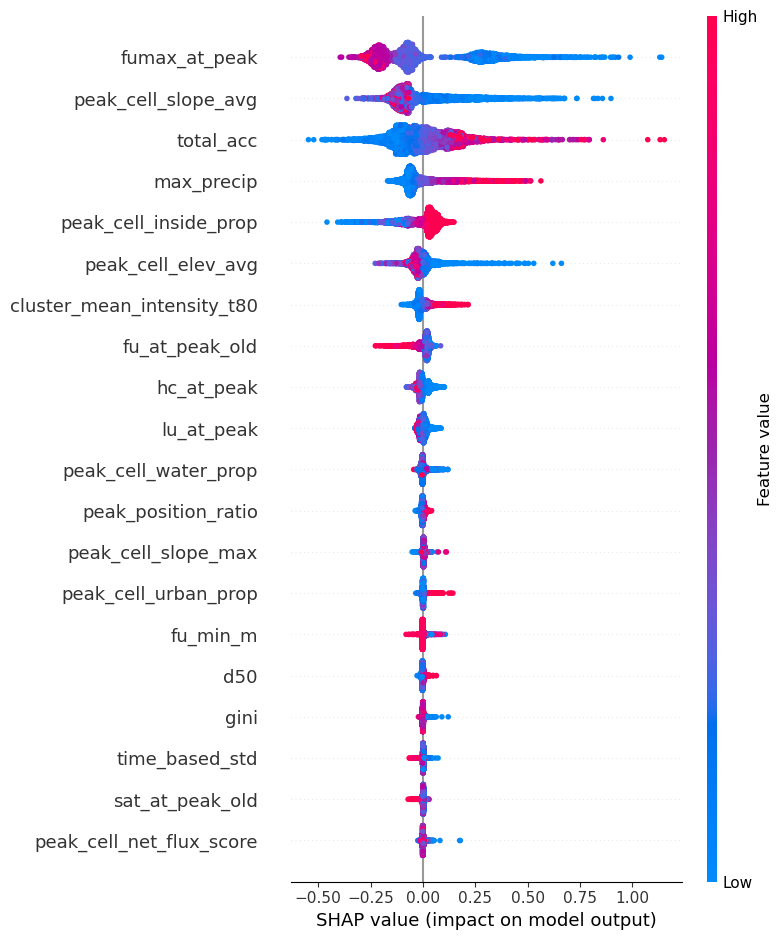

In [102]:
shap_values = explainer.shap_values(X)

# Global summary: which variables matter most overall, and in which direction
shap.summary_plot(shap_values, X, show=True)